### Data Collection + Data Cleaning + Data Transformation = Data Preparation

The block below shows how to set up our Python environment for a data analysis project. 
It demonstrates awareness of:

- Data cleaning (pandas, numpy)
- Visualization (matplotlib, seaborn, plotly)
- Handling missing data (missingno)
- String cleaning and matching (re, fuzzywuzzy)
- File handling (os)
- Code hygiene (suppressing warnings for clean notebook output)

In [87]:
# Data manipulation libraries

import pandas as pd  # Core library for data manipulation and analysis (DataFrames)
import numpy as np   # Fundamental library for numerical operations and arrays


# Data visualization libraries

import seaborn as sns               # Statistical data visualization built on matplotlib
import matplotlib.pyplot as plt     # Standard Python plotting library
import plotly.express as px         # Interactive, high-level plotting library
import plotly.graph_objects as go   # Detailed control over interactive Plotly plots
import plotly.subplots as sp       # Allows creating subplots/grids for multiple charts


# Missing data visualization

import missingno as msno  # Visualize and explore missing values in datasets

# String manipulation

import re  # Regular expressions for pattern matching in strings

# File system interaction
import os  # Handle file paths, directories, and other OS interactions

# Fuzzy matching for string comparison
from fuzzywuzzy import process  # Useful for approximate string matching (e.g., country names)

# Suppress warnings for clean output (by ignoring warning messages)
import warnings
warnings.filterwarnings('ignore')  

The code below shows the ability to fetch data directly from the web (in this case, using web scraping technique).

Demonstrates understanding of the ETL (Extract, Transform, Load) process starting from raw HTML.

Using BeautifulSoup and requests is standard practice for data collection when APIs are not available.

In [88]:
# Install and import libraries for web scraping

# Install (or update) BeautifulSoup4, a library to parse and extract data from HTML
!pip install bs4

# Import BeautifulSoup to analyze HTML content and extract tables, links, or text
from bs4 import BeautifulSoup

# Import requests to send HTTP requests and retrieve webpage content
import requests

The code below, shows ability to fetch data from the web programmatically.

Demonstrates handling of HTTP requests, checking status codes.

Reads and inspects HTML tables directly into pandas DataFrames.

Clear separation by gender for easier downstream processing.

### Data Collection

In [89]:
# Dictionary containing URLs for men's and women's Olympic swimming medalists
urls = {
    "men": "https://en.wikipedia.org/wiki/List_of_Olympic_medalists_in_swimming_(men)",
    "women": "https://en.wikipedia.org/wiki/List_of_Olympic_medalists_in_swimming_(women)"
}

# Headers to avoid HTTP 403 Forbidden errors
headers = {'User-Agent': 'Mozilla/5.0'}

# Dictionary to store all tables fetched from each URL
all_tables = {}

for gender, url in urls.items():
    # Fetch the HTML content from the URL
    response = requests.get(url, headers=headers)
    print(f"\nURL: {url} - Status code: {response.status_code}")

    if response.status_code == 200:
        # Read all tables in the HTML into pandas DataFrames
        tables = pd.read_html(response.text)
        print(f" - {len(tables)} tables found for {gender}")
        all_tables[gender] = tables

        # Display the first 2 tables for quick inspection
        for i, table in enumerate(tables[:2], start=1):
            print(f"\nTable {i} ({gender}):")
            display(table)
    else:
        print(f" - Could not access {url} (Status code {response.status_code})")


URL: https://en.wikipedia.org/wiki/List_of_Olympic_medalists_in_swimming_(men) - Status code: 200
 - 45 tables found for men

Table 1 (men):


,0,1
0,OR,indicates swimmer broke the Olympic Record
1,WR,indicates swimmer broke the World Record (and ...
2,AM,indicates swimmer broke the American Record
3,SA,indicates swimmer broke the South American Record
4,ER,indicates swimmer broke the European Record
5,AS,indicates swimmer broke the Asian Record
6,NR,indicates swimmer broke the National Record



Table 2 (men):


,Games,Gold,Gold.1,Silver,Silver.1,Bronze,Bronze.1
0,1988 Seoul details,Matt Biondi United States,22.14 WR,Tom Jager United States,22.36,Gennadiy Prigoda Soviet Union,22.71
1,1992 Barcelona details,Alexander Popov Unified Team,21.91 OR,Matt Biondi United States,22.09,Tom Jager United States,22.30
2,1996 Atlanta details,Alexander Popov Russia,22.13,Gary Hall Jr. United States,22.26,Fernando Scherer Brazil,22.29 SA
3,2000 Sydney details,Anthony Ervin United States Gary Hall Jr. Un...,21.98,Not awarded as there was a tie for gold.,Not awarded as there was a tie for gold.,Pieter van den Hoogenband Netherlands,22.03
4,2004 Athens details,Gary Hall Jr. United States,21.93,Duje Draganja Croatia,21.94,Roland Mark Schoeman South Africa,22.02
5,2008 Beijing details,César Cielo Brazil,21.30 OR AM,Amaury Leveaux France,21.45,Alain Bernard France,21.49
6,2012 London details,Florent Manaudou France,21.34,Cullen Jones United States,21.54,César Cielo Brazil,21.59
7,2016 Rio de Janeiro details,Anthony Ervin United States,21.40,Florent Manaudou France,21.41,Nathan Adrian United States,21.49
8,2020 Tokyo details,Caeleb Dressel United States,21.07 OR,Florent Manaudou France,21.55,Bruno Fratus Brazil,21.57
9,2024 Paris details,Cameron McEvoy Australia,21.25,Benjamin Proud Great Britain,21.30,Florent Manaudou France,21.56



URL: https://en.wikipedia.org/wiki/List_of_Olympic_medalists_in_swimming_(women) - Status code: 200
 - 23 tables found for women

Table 1 (women):


,Games,Gold,Silver,Bronze
0,1988 Seoul details,Kristin Otto East Germany,Yang Wenyi China,Katrin Meissner East Germany
1,1988 Seoul details,Kristin Otto East Germany,Yang Wenyi China,Jill Sterkel United States
2,1992 Barcelona details,Yang Wenyi China,Zhuang Yong China,Angel Martino United States
3,1996 Atlanta details,Amy Van Dyken United States,Le Jingyi China,Sandra Völker Germany
4,2000 Sydney details,Inge de Bruijn Netherlands,Therese Alshammar Sweden,Dara Torres United States
5,2004 Athens details,Inge de Bruijn Netherlands,Malia Metella France,Libby Lenton Australia
6,2008 Beijing details,Britta Steffen Germany,Dara Torres United States,Cate Campbell Australia
7,2012 London details,Ranomi Kromowidjojo Netherlands,Aliaksandra Herasimenia Belarus,Marleen Veldhuis Netherlands
8,2016 Rio de Janeiro details,Pernille Blume Denmark,Simone Manuel United States,Aliaksandra Herasimenia Belarus
9,2020 Tokyo details,Emma McKeon Australia,Sarah Sjöström Sweden,Pernille Blume Denmark



Table 2 (women):


,Games,Gold,Silver,Bronze
0,1912 Stockholm details,Fanny Durack Australasia,Wilhelmina Wylie Australasia,Jennie Fletcher Great Britain
1,1920 Antwerp details,Ethelda Bleibtrey United States,Irene Guest United States,Frances Schroth United States
2,1924 Paris details,Ethel Lackie United States,Mariechen Wehselau United States,Gertrude Ederle United States
3,1928 Amsterdam details,Albina Osipowich United States,Eleanor Garatti United States,Joyce Cooper Great Britain
4,1932 Los Angeles details,Helene Madison United States,Willy den Ouden Netherlands,Eleanor Saville United States
5,1936 Berlin details,Rie Mastenbroek Netherlands,Jeannette Campbell Argentina,Gisela Arendt Germany
6,1948 London details,Greta Andersen Denmark,Ann Curtis United States,Marie-Louise Linssen-Vaessen Netherlands
7,1952 Helsinki details,Katalin Szőke Hungary,Hannie Termeulen Netherlands,Judit Temes Hungary
8,1956 Melbourne details,Dawn Fraser Australia,Lorraine Crapp Australia,Faith Leech Australia
9,1960 Rome details,Dawn Fraser Australia,Chris von Saltza United States,Natalie Steward Great Britain


In [90]:
# Create a "blacklist" of tables to exclude – these tables have a different structure or contain irrelevant information

blacklist_terms = [
    "All-time medal table", "Medal Table", "Youngest and oldest", 
    "Records", "Timeline", "Team", "4 ×", "yard freestyle", 
    "Underwater swimming", "yard", "mile", "marathon", "obstacle race"
]

blacklist_info = []

# Iterate over genders and their tables
for gender, tables in all_tables.items():
    for i, df_tmp in enumerate(tables):
        # Use column name as title if exists, otherwise use index
        title = df_tmp.columns.name if df_tmp.columns.name else f"Table_{i}" # Use the column name as the table title if available; otherwise, create an automatic name like "Table_0", "Table_1", etc.
    
       # df_tmp = Temporary variable for each table while iterating – allows us to inspect structure and metadata without altering the original data
       # Check if table title contains any term in the blacklist
        if any(term.lower() in title.lower() for term in blacklist_terms):
            blacklist_info.append({
                "Gender": gender,
                "Table_Index": i,
                "Original_Title": title,
                "Num_Rows": df_tmp.shape[0],
                "Num_Cols": df_tmp.shape[1]
            })

# Convert the blacklist info to a DataFrame
df_blacklist = pd.DataFrame(blacklist_info)

In [91]:
# Iterate over all tables for both genders to inspect them
# Commented out to avoid cluttering the output

# for gender, tables in all_tables.items():
#     print(f"\n{gender} - Total tables: {len(tables)}")
#     for i, table in enumerate(tables, start=1):
#         print(f"\nTable {i} ({gender}):")
#         display(table.head(3))  # Display only first 3 rows to keep output manageable

In [92]:
# List of key countries to help identify athlete's country in merged Wikipedia cells
countries_list = [ 'Russia','France','United States','Soviet Union','Netherlands','Brazil',
                   'East Germany','South Africa','Australia','Great Britain','Croatia','Unified Team' ] # This list helps automatically detect the country from a cell that merges athlete name and country

def split_athlete_country(cell):
    """
    Split athlete name and country from a single cell.
    Wikipedia tables often merge athlete and country in one cell.
    This function normalizes that into separate columns.
    """
    
    # Each cell is treated like a mini puzzle: extract athlete name and country while keeping the data clean and structured


    # Return None if cell is empty
    if pd.isna(cell):
        return pd.Series([None, None])
    
    # Clean string: remove extra spaces
    cell = str(cell).strip()
    country_found = None
    athlete = None

    # Try to match the country from the predefined list
    for country in countries_list:
        if cell.endswith(country):
            country_found = country
            athlete = cell.replace(country, "").strip()  # Remove country to isolate athlete's name
            break

    # "Fallback Rule": assume the last word is the country if no match found - Everything that comes before the last word is considered the athlete's name, regardless of how many first or last names they have

    if not country_found:
        parts = cell.split()
        if len(parts) > 1:
            athlete = " ".join(parts[:-1])  # All words except last -> athlete
            country_found = parts[-1]       # Last word -> country
        else:
            athlete = cell
            country_found = None

    # Return as two separate columns: [athlete_name, country]
    return pd.Series([athlete, country_found])

In [93]:
def split_time_record(cell):
    """
    Extracts time and record from a cell, keeping original formatting.
    If no record is found, returns 'No_Record'.
    """
    
    # Return default values if cell is empty
    if pd.isna(cell):
        return pd.Series([None, "No_Record"])
    
    # Clean the string: remove extra spaces
    cell = str(cell).strip()
    
    # Extract time (minutes:seconds.milliseconds or seconds.milliseconds)
    time_match = re.search(r'\d+:\d+\.\d+|\d+\.\d+', cell)
    time = None
    if time_match:
        time = time_match.group()
        
        # Convert "minutes:seconds" format to total seconds
        if ":" in time:
            minutes, seconds = time.split(":")
            time = float(minutes)*60 + float(seconds)
        else:
            time = float(time)
    
    # Extract records (WR, OR, AM, SA, ER)
    records = re.findall(r'\b(WR|OR|AM|SA|ER)\b', cell)
    record_str = " ".join(records) if records else "No_Record"
    
    # Return as two separate columns: [time_in_seconds, record_string]
    return pd.Series([time, record_str])

In [94]:
cleaned_tables = []     # Stores all cleaned event-level tables
medal_tables = []       # Stores All-Time Medal Tables (Rank / Nation / Gold / Silver / Bronze)

for gender, url in urls.items():

    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")
    tables = soup.find_all("table", {"class": "wikitable"})

    for table in tables:
        df = pd.read_html(str(table))[0]

        # CAPTURE ALL-TIME MEDAL TABLES (Rank / Nation / Total)
        # These tables have a completely different structure from event results.
        # We save them separately and skip all further processing.

        if all(col in df.columns for col in ["Rank", "Nation", "Gold", "Silver", "Bronze", "Total"]):
            df["Gender"] = gender
            medal_tables.append(df)
            continue   # Skip to next table — no cleaning needed


        # FILTER ONLY EVENT RESULT TABLES
        # Event tables always contain Games + Gold/Silver/Bronze results.
        # If a table doesn't match this structure → skip it.

        if not all(col in df.columns for col in ["Games", "Gold", "Silver", "Bronze"]):
            continue


        # EXTRACT EVENT TITLE, DISTANCE, STYLE
        # We pull the event name from <caption> or the previous page heading.
        # Then we try to split it into distance (e.g., "100m") and style ("Freestyle").

        caption = table.find("caption")
        if caption and caption.text.strip():
            event_title = caption.text.strip()
        else:
            prev_heading = table.find_previous(["h2", "h3"])
            event_title = prev_heading.text.strip() if prev_heading else None

        # Remove "details" from Wikipedia formatting
        if event_title:
            event_title = event_title.replace("details", "").strip()

        # Try extracting "distance" and "style"
        distance = None
        style = None
        if event_title:
            m = re.match(r"(\d+.*?m)\s*(.+)", event_title)
            if m:
                distance = m.group(1)
                style = m.group(2)
            else:
                style = event_title

        df['Event_Title'] = event_title
        df['Distance'] = distance
        df['Style'] = style


        # SKIP UNWANTED TABLE TYPES
        # Prevents capturing historical, record, or aggregated tables.

        blacklist = [
            "All-time medal table",
            "Medal Table",
            "Youngest and oldest",
            "Records",
            "Timeline",
            "Team",
            "4 ×",
            "yard freestyle",
            "Underwater swimming",
            "yard",
            "mile",
            "marathon",
            "obstacle race"
        ]

        if event_title:
            if any(term.lower() in event_title.lower() for term in blacklist):
                continue

        # CLEAN GOLD / SILVER / BRONZE COLUMNS
        # Extract:
        #   Athlete Name
        #   Country
        #   Time
        #   Record (e.g., OR, WR)

        df = df.replace('\s+', ' ', regex=True)

        for medal in ["Gold", "Silver", "Bronze"]:

            # Extract athlete + country
            df[[f"{medal}_Athlete", f"{medal}_Country"]] = df[medal].apply(split_athlete_country)

            # Time + Record (may exist as Gold.1, Silver.1, Bronze.1)
            time_col = f"{medal}.1"
            if time_col in df.columns:
              df[[f"{medal}_Time", f"{medal}_Record"]] = df[time_col].apply(split_time_record)
            else:
              df[[f"{medal}_Time", f"{medal}_Record"]] = pd.DataFrame(
                [[None, "No_Record"]] * len(df),
                columns=[f"{medal}_Time", f"{medal}_Record"]
              )

        # Drop original raw columns
        cols_to_drop = ["Gold","Silver","Bronze","Gold.1","Silver.1","Bronze.1"]
        df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


        # Clean Games column (remove "details")
        if 'Games' in df.columns:
            df['Games'] = df['Games'].str.replace('details', '').str.strip()

        df['Gender'] = gender
        cleaned_tables.append(df)

# FINAL MERGE — Two final datasets:
#    df_final  -> all cleaned event-level results
#    df_medals -> all-time medal tables (Men + Women)

df_final = pd.concat(cleaned_tables, ignore_index=True)
df_medals = pd.concat(medal_tables, ignore_index=True)

In [95]:
# Merge all cleaned event-level tables into one standardized dataset
df_final = pd.concat(cleaned_tables, ignore_index=True)

# Quick Data Validation 
display(df_final.head(50))   # Preview first rows to ensure structure is correct
print(df_final.shape)        # Check total number of rows and columns
print(df_final.columns)      # Confirm all expected cleaned fields are present

,Games,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
0,1988 Seoul,50 metre freestyle,50 m,etre freestyle,Matt Biondi,United States,22.14,WR,Tom Jager,United States,22.36,No_Record,Gennadiy Prigoda,Soviet Union,22.71,No_Record,men
1,1992 Barcelona,50 metre freestyle,50 m,etre freestyle,Alexander Popov,Unified Team,21.91,OR,Matt Biondi,United States,22.09,No_Record,Tom Jager,United States,22.30,No_Record,men
2,1996 Atlanta,50 metre freestyle,50 m,etre freestyle,Alexander Popov,Russia,22.13,No_Record,Gary Hall Jr.,United States,22.26,No_Record,Fernando Scherer,Brazil,22.29,SA,men
3,2000 Sydney,50 metre freestyle,50 m,etre freestyle,Anthony Ervin Gary Hall Jr.,United States,21.98,No_Record,Not awarded as there was a tie for,gold.,NaN,No_Record,Pieter van den Hoogenband,Netherlands,22.03,No_Record,men
4,2004 Athens,50 metre freestyle,50 m,etre freestyle,Gary Hall Jr.,United States,21.93,No_Record,Duje Draganja,Croatia,21.94,No_Record,Roland Mark Schoeman,South Africa,22.02,No_Record,men
5,2008 Beijing,50 metre freestyle,50 m,etre freestyle,César Cielo,Brazil,21.30,OR AM,Amaury Leveaux,France,21.45,No_Record,Alain Bernard,France,21.49,No_Record,men
6,2012 London,50 metre freestyle,50 m,etre freestyle,Florent Manaudou,France,21.34,No_Record,Cullen Jones,United States,21.54,No_Record,César Cielo,Brazil,21.59,No_Record,men
7,2016 Rio de Janeiro,50 metre freestyle,50 m,etre freestyle,Anthony Ervin,United States,21.40,No_Record,Florent Manaudou,France,21.41,No_Record,Nathan Adrian,United States,21.49,No_Record,men
8,2020 Tokyo,50 metre freestyle,50 m,etre freestyle,Caeleb Dressel,United States,21.07,OR,Florent Manaudou,France,21.55,No_Record,Bruno Fratus,Brazil,21.57,No_Record,men
9,2024 Paris,50 metre freestyle,50 m,etre freestyle,Cameron McEvoy,Australia,21.25,No_Record,Benjamin Proud,Great Britain,21.30,No_Record,Florent Manaudou,France,21.56,No_Record,men


(509, 17)
Index(['Games', 'Event_Title', 'Distance', 'Style', 'Gold_Athlete',
       'Gold_Country', 'Gold_Time', 'Gold_Record', 'Silver_Athlete',
       'Silver_Country', 'Silver_Time', 'Silver_Record', 'Bronze_Athlete',
       'Bronze_Country', 'Bronze_Time', 'Bronze_Record', 'Gender'],
      dtype='object')


In [96]:
df_final['Event_Title'].unique()

array(['50 metre freestyle', '100 metre freestyle', '200 metre freestyle',
       '400 metre freestyle', '800 metre freestyle',
       '1500 metre freestyle', '100 metre backstroke',
       '200 metre backstroke', '100 metre breaststroke',
       '200 metre breaststroke', '100 metre butterfly',
       '200 metre butterfly', '200 metre individual medley',
       '400 metre individual medley', '100 metre for sailors',
       '500 metre freestyle', '1000 metre freestyle',
       '1200 metre freestyle', '4000 metre freestyle',
       '400 metre breaststroke', '300 metre freestyle'], dtype=object)

In [97]:
from IPython.display import display

#  Clean Distance 
# Remove 'm' from Distance column
if 'Distance' in df_final.columns:
    df_final['Distance'] = df_final['Distance'].str.replace('m', '', regex=False).str.strip()

# ----------- Clean Style -----------
# Remove 'etre' from Style column (if exists)
if 'Style' in df_final.columns:
    df_final['Style'] = df_final['Style'].str.replace('etre', '', regex=False).str.strip()

# ----------- Clean Event_Title -----------
# Optional: remove extra spaces
if 'Event_Title' in df_final.columns:
    df_final['Event_Title'] = df_final['Event_Title'].str.strip()

# ----------- Clean Games -----------
# Remove unwanted words from Games column
if 'Games' in df_final.columns:
    df_final['Games'] = df_final['Games'].str.replace('displays', '', regex=False).str.strip()

# ----------- Extract Year from Games -----------
# Create a new column Games_Year with only the year (integer)
if 'Games' in df_final.columns:
    games_year = df_final['Games'].str.extract(r'(\d{4})')[0].astype(int)
    # Insert the new column next to 'Games'
    df_final.insert(loc=df_final.columns.get_loc('Games') + 1,
                    column='Games_Year',
                    value=games_year)

# ----------- Display cleaned DataFrame safely -----------
# Use display() to avoid debugger JSON dump
print("Preview of cleaned data:")
display(df_final.head(10))

print("\nGames and Games_Year columns:")
display(df_final[['Games', 'Games_Year']].head(10))


Preview of cleaned data:


,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
0,1988 Seoul,1988,50 metre freestyle,50,freestyle,Matt Biondi,United States,22.14,WR,Tom Jager,United States,22.36,No_Record,Gennadiy Prigoda,Soviet Union,22.71,No_Record,men
1,1992 Barcelona,1992,50 metre freestyle,50,freestyle,Alexander Popov,Unified Team,21.91,OR,Matt Biondi,United States,22.09,No_Record,Tom Jager,United States,22.30,No_Record,men
2,1996 Atlanta,1996,50 metre freestyle,50,freestyle,Alexander Popov,Russia,22.13,No_Record,Gary Hall Jr.,United States,22.26,No_Record,Fernando Scherer,Brazil,22.29,SA,men
3,2000 Sydney,2000,50 metre freestyle,50,freestyle,Anthony Ervin Gary Hall Jr.,United States,21.98,No_Record,Not awarded as there was a tie for,gold.,NaN,No_Record,Pieter van den Hoogenband,Netherlands,22.03,No_Record,men
4,2004 Athens,2004,50 metre freestyle,50,freestyle,Gary Hall Jr.,United States,21.93,No_Record,Duje Draganja,Croatia,21.94,No_Record,Roland Mark Schoeman,South Africa,22.02,No_Record,men
5,2008 Beijing,2008,50 metre freestyle,50,freestyle,César Cielo,Brazil,21.30,OR AM,Amaury Leveaux,France,21.45,No_Record,Alain Bernard,France,21.49,No_Record,men
6,2012 London,2012,50 metre freestyle,50,freestyle,Florent Manaudou,France,21.34,No_Record,Cullen Jones,United States,21.54,No_Record,César Cielo,Brazil,21.59,No_Record,men
7,2016 Rio de Janeiro,2016,50 metre freestyle,50,freestyle,Anthony Ervin,United States,21.40,No_Record,Florent Manaudou,France,21.41,No_Record,Nathan Adrian,United States,21.49,No_Record,men
8,2020 Tokyo,2020,50 metre freestyle,50,freestyle,Caeleb Dressel,United States,21.07,OR,Florent Manaudou,France,21.55,No_Record,Bruno Fratus,Brazil,21.57,No_Record,men
9,2024 Paris,2024,50 metre freestyle,50,freestyle,Cameron McEvoy,Australia,21.25,No_Record,Benjamin Proud,Great Britain,21.30,No_Record,Florent Manaudou,France,21.56,No_Record,men



Games and Games_Year columns:


,Games,Games_Year
0,1988 Seoul,1988
1,1992 Barcelona,1992
2,1996 Atlanta,1996
3,2000 Sydney,2000
4,2004 Athens,2004
5,2008 Beijing,2008
6,2012 London,2012
7,2016 Rio de Janeiro,2016
8,2020 Tokyo,2020
9,2024 Paris,2024


In [98]:
# Create separate copies for exploratory data analysis (EDA)
# Keeps the original cleaned datasets intact for future use
df_eda = df_final.copy() # Event-level results (Men + Women)
df_eda_medals = df_medals.copy() # All-Time Medal Tables (Men + Women)

In [99]:
df_medals

,Rank,Nation,Gold,Silver,Bronze,Total,Gender
0,1,United States,143,100,71,314,men
1,2,Australia,33,37,38,108,men
2,3,Germany,18,22,26,66,men
3,4,Japan,17,22,21,60,men
4,5,Hungary,16,17,13,46,men
...,...,...,...,...,...,...,...
80,36,Belgium,0,0,1,1,women
81,36,Mexico,0,0,1,1,women
82,36,New Zealand,0,0,1,1,women
83,36,Norway,0,0,1,1,women


In [100]:
# Extract the country name and acronym using regex
df_medals[['Country', 'Acronym']] = df_medals['Nation'].str.extract(r'^(.*?)\s*\((.*?)\)$')

In [101]:
df_medals  # Display the df_medals DataFrame for visualization

,Rank,Nation,Gold,Silver,Bronze,Total,Gender,Country,Acronym
0,1,United States,143,100,71,314,men,NaN,NaN
1,2,Australia,33,37,38,108,men,NaN,NaN
2,3,Germany,18,22,26,66,men,NaN,NaN
3,4,Japan,17,22,21,60,men,NaN,NaN
4,5,Hungary,16,17,13,46,men,NaN,NaN
...,...,...,...,...,...,...,...,...,...
80,36,Belgium,0,0,1,1,women,NaN,NaN
81,36,Mexico,0,0,1,1,women,NaN,NaN
82,36,New Zealand,0,0,1,1,women,NaN,NaN
83,36,Norway,0,0,1,1,women,NaN,NaN


### EDA — Exploratory Data Analysis

In [102]:
def initial_exploration(df, dataset_type=None):
    print("1. Number of rows and columns in the dataset:")
    num_rows, num_columns = df.shape
    print(f"\tThere are {num_rows:,} rows and {num_columns:,} columns")
    print('\n' + '-'*90 + '\n')

    print("2. First five rows of the dataset:")
    display(df.head())
    print('\n' + '-'*90 + '\n')

    print("3. Last five rows of the dataset:")
    display(df.tail())
    print('\n' + '-'*90 + '\n')

    print("4. Random sample of rows from the dataset (fixed sample):")
    display(df.sample(n=5, random_state=42))
    print('\n' + '-'*90 + '\n')

    print("5. Columns in the dataset are:")
    for col in df.columns:
        print(f"\t - {col}")
    print('\n' + '-'*90 + '\n')

    print("6. Data type of each column:")
    print(df.dtypes)
    print('\n' + '-'*90 + '\n')

    print("7. Number of columns per data type:")
    print(df.dtypes.value_counts())
    print('\n' + '-'*90 + '\n')

    print("8. Detailed info about the structure and contents of the DataFrame:")
    print(df.info())
    print('\n' + '-'*90 + '\n')

    print("9. Number of unique values in each column:")
    print(df.nunique())
    print('\n' + '-'*90 + '\n')

    print("10. Basic descriptive statistics for all columns:")
    display(df.describe(include='all').fillna(''))
    print('\n' + '-'*90 + '\n')

    print("11. Check for null values in each column:")
    print(df.isnull().sum().sort_values(ascending=False))
    print('\n' + '-'*90 + '\n')

    print("12. Percentage of null values in each column:")
    print(round((df.isnull().sum()/len(df)*100), 2).sort_values(ascending=False))
    print('\n' + '-'*90 + '\n')

In [103]:
for gender in ['men', 'women']:
    print(f"--- EXPLORATION FOR {gender.upper()} ---")
    initial_exploration(df_eda[df_eda['Gender'] == gender].copy())


--- EXPLORATION FOR MEN ---
1. Number of rows and columns in the dataset:
	There are 269 rows and 18 columns

------------------------------------------------------------------------------------------

2. First five rows of the dataset:


,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
0,1988 Seoul,1988,50 metre freestyle,50,freestyle,Matt Biondi,United States,22.14,WR,Tom Jager,United States,22.36,No_Record,Gennadiy Prigoda,Soviet Union,22.71,No_Record,men
1,1992 Barcelona,1992,50 metre freestyle,50,freestyle,Alexander Popov,Unified Team,21.91,OR,Matt Biondi,United States,22.09,No_Record,Tom Jager,United States,22.30,No_Record,men
2,1996 Atlanta,1996,50 metre freestyle,50,freestyle,Alexander Popov,Russia,22.13,No_Record,Gary Hall Jr.,United States,22.26,No_Record,Fernando Scherer,Brazil,22.29,SA,men
3,2000 Sydney,2000,50 metre freestyle,50,freestyle,Anthony Ervin Gary Hall Jr.,United States,21.98,No_Record,Not awarded as there was a tie for,gold.,NaN,No_Record,Pieter van den Hoogenband,Netherlands,22.03,No_Record,men
4,2004 Athens,2004,50 metre freestyle,50,freestyle,Gary Hall Jr.,United States,21.93,No_Record,Duje Draganja,Croatia,21.94,No_Record,Roland Mark Schoeman,South Africa,22.02,No_Record,men



------------------------------------------------------------------------------------------

3. Last five rows of the dataset:


,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
264,1900 Paris,1900,1000 metre freestyle,1000,freestyle,John Arthur Jarvis,Great Britain,NaN,No_Record,Otto Wahle,Austria,NaN,No_Record,Zoltán Halmay,Hungary,NaN,No_Record,men
265,1896 Athens,1896,1200 metre freestyle,1200,freestyle,Alfréd Hajós,Hungary,NaN,No_Record,Ioannis Andreou,Greece,NaN,No_Record,none,awarded[1],NaN,No_Record,men
266,1900 Paris,1900,4000 metre freestyle,4000,freestyle,John Arthur Jarvis,Great Britain,NaN,No_Record,Zoltán Halmay,Hungary,NaN,No_Record,Louis Martin,France,NaN,No_Record,men
267,1912 Stockholm,1912,400 metre breaststroke,400,breaststroke,Walter Bathe,Germany,NaN,No_Record,Thor Henning,Sweden,NaN,No_Record,Percy Courtman,Great Britain,NaN,No_Record,men
268,1920 Antwerp,1920,400 metre breaststroke,400,breaststroke,Håkan Malmrot,Sweden,NaN,No_Record,Thor Henning,Sweden,NaN,No_Record,Arvo Aaltonen,Finland,NaN,No_Record,men



------------------------------------------------------------------------------------------

4. Random sample of rows from the dataset (fixed sample):


...


------------------------------------------------------------------------------------------

4. Random sample of rows from the dataset (fixed sample):


,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
293,1976 Montreal,1976,100 metre freestyle,100,freestyle,Kornelia Ender,East Germany,NaN,No_Record,Petra Priemer,East Germany,NaN,No_Record,Enith Brigitha,Netherlands,NaN,No_Record,women
275,2008 Beijing,2008,50 metre freestyle,50,freestyle,Britta Steffen,Germany,NaN,No_Record,Dara Torres,United States,NaN,No_Record,Cate Campbell,Australia,NaN,No_Record,women
362,2024 Paris,2024,800 metre freestyle,800,freestyle,Katie Ledecky,United States,NaN,No_Record,Ariarne Titmus,Australia,NaN,No_Record,Paige Madden,United States,NaN,No_Record,women
378,1984 Los Angeles,1984,100 metre backstroke,100,backstroke,Theresa Andrews,United States,NaN,No_Record,Betsy Mitchell,United States,NaN,No_Record,Jolanda de Rover,Netherlands,NaN,No_Record,women
373,1964 Tokyo,1964,100 metre backstroke,100,backstroke,Cathy Ferguson,United States,NaN,No_Record,Kiki Caron,France,NaN,No_Record,Ginny Duenkel,United States,NaN,No_Record,women



------------------------------------------------------------------------------------------

5. Columns in the dataset are:
	 - Games
	 - Games_Year
	 - Event_Title
	 - Distance
	 - Style
	 - Gold_Athlete
	 - Gold_Country
	 - Gold_Time
	 - Gold_Record
	 - Silver_Athlete
	 - Silver_Country
	 - Silver_Time
	 - Silver_Record
	 - Bronze_Athlete
	 - Bronze_Country
	 - Bronze_Time
	 - Bronze_Record
	 - Gender

------------------------------------------------------------------------------------------

6. Data type of each column:
Games              object
Games_Year          int64
Event_Title        object
Distance           object
Style              object
Gold_Athlete       object
Gold_Country       object
Gold_Time         float64
Gold_Record        object
Silver_Athlete     object
Silver_Country     object
Silver_Time       float64
Silver_Record      object
Bronze_Athlete     object
Bronze_Country     object
Bronze_Time       float64
Bronze_Record      object
Gender             object
dty

,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
count,240,240.0,240,240,240,240,240,0.0,240,240,240,0.0,240,240,240,0.0,240,240
unique,27,,15,7,5,162,29,,1,191,33,,1,203,33,,1,1
top,2016 Rio de Janeiro,,100 metre freestyle,100,freestyle,Katie Ledecky,United States,,No_Record,Shirley Babashoff,United States,,No_Record,Angel Martino,United States,,No_Record,women
freq,15,,29,87,97,8,81,,240,5,77,,240,3,69,,240,240
mean,,1987.533333,,,,,,,,,,,,,,,,
std,,26.455594,,,,,,,,,,,,,,,,
min,,1912.0,,,,,,,,,,,,,,,,
25%,,1972.0,,,,,,,,,,,,,,,,
50%,,1992.0,,,,,,,,,,,,,,,,
75%,,2008.0,,,,,,,,,,,,,,,,



------------------------------------------------------------------------------------------

11. Check for null values in each column:
Silver_Time       240
Gold_Time         240
Bronze_Time       240
Games               0
Games_Year          0
Event_Title         0
Gold_Athlete        0
Gold_Country        0
Style               0
Distance            0
Silver_Athlete      0
Gold_Record         0
Silver_Record       0
Silver_Country      0
Bronze_Athlete      0
Bronze_Country      0
Bronze_Record       0
Gender              0
dtype: int64

------------------------------------------------------------------------------------------

12. Percentage of null values in each column:
Silver_Time       100.0
Gold_Time         100.0
Bronze_Time       100.0
Games               0.0
Games_Year          0.0
Event_Title         0.0
Gold_Athlete        0.0
Gold_Country        0.0
Style               0.0
Distance            0.0
Silver_Athlete      0.0
Gold_Record         0.0
Silver_Record       0.0
Silve

In [104]:
df_eda.head(10) # Preview the first 10 rows of df_eda

,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,Silver_Country,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender
0,1988 Seoul,1988,50 metre freestyle,50,freestyle,Matt Biondi,United States,22.14,WR,Tom Jager,United States,22.36,No_Record,Gennadiy Prigoda,Soviet Union,22.71,No_Record,men
1,1992 Barcelona,1992,50 metre freestyle,50,freestyle,Alexander Popov,Unified Team,21.91,OR,Matt Biondi,United States,22.09,No_Record,Tom Jager,United States,22.30,No_Record,men
2,1996 Atlanta,1996,50 metre freestyle,50,freestyle,Alexander Popov,Russia,22.13,No_Record,Gary Hall Jr.,United States,22.26,No_Record,Fernando Scherer,Brazil,22.29,SA,men
3,2000 Sydney,2000,50 metre freestyle,50,freestyle,Anthony Ervin Gary Hall Jr.,United States,21.98,No_Record,Not awarded as there was a tie for,gold.,NaN,No_Record,Pieter van den Hoogenband,Netherlands,22.03,No_Record,men
4,2004 Athens,2004,50 metre freestyle,50,freestyle,Gary Hall Jr.,United States,21.93,No_Record,Duje Draganja,Croatia,21.94,No_Record,Roland Mark Schoeman,South Africa,22.02,No_Record,men
5,2008 Beijing,2008,50 metre freestyle,50,freestyle,César Cielo,Brazil,21.30,OR AM,Amaury Leveaux,France,21.45,No_Record,Alain Bernard,France,21.49,No_Record,men
6,2012 London,2012,50 metre freestyle,50,freestyle,Florent Manaudou,France,21.34,No_Record,Cullen Jones,United States,21.54,No_Record,César Cielo,Brazil,21.59,No_Record,men
7,2016 Rio de Janeiro,2016,50 metre freestyle,50,freestyle,Anthony Ervin,United States,21.40,No_Record,Florent Manaudou,France,21.41,No_Record,Nathan Adrian,United States,21.49,No_Record,men
8,2020 Tokyo,2020,50 metre freestyle,50,freestyle,Caeleb Dressel,United States,21.07,OR,Florent Manaudou,France,21.55,No_Record,Bruno Fratus,Brazil,21.57,No_Record,men
9,2024 Paris,2024,50 metre freestyle,50,freestyle,Cameron McEvoy,Australia,21.25,No_Record,Benjamin Proud,Great Britain,21.30,No_Record,Florent Manaudou,France,21.56,No_Record,men


In [105]:
df_eda['Gold_Record'].unique()

array(['WR', 'OR', 'No_Record', 'OR AM', 'OR ER'], dtype=object)

In [106]:
print(df_eda['Distance'].dtype)

object


In [107]:
df_eda['Distance'].unique()


array(['50', '100', '200', '400', '800', '1500', '500', '1000', '1200',
       '4000', '300'], dtype=object)

In [108]:
df_eda['Distance'] = df_eda['Distance'].astype(int)


In [109]:
print(df_eda['Distance'].dtype)

int64


In [110]:
print(df_eda.dtypes)

Games              object
Games_Year          int64
Event_Title        object
Distance            int64
Style              object
Gold_Athlete       object
Gold_Country       object
Gold_Time         float64
Gold_Record        object
Silver_Athlete     object
Silver_Country     object
Silver_Time       float64
Silver_Record      object
Bronze_Athlete     object
Bronze_Country     object
Bronze_Time       float64
Bronze_Record      object
Gender             object
dtype: object


In [111]:
df_eda['Games'].unique()


array(['1988 Seoul', '1992 Barcelona', '1996 Atlanta', '2000 Sydney',
       '2004 Athens', '2008 Beijing', '2012 London',
       '2016 Rio de Janeiro', '2020 Tokyo', '2024 Paris', '1896 Athens',
       '1900–1904', '1908 London', '1912 Stockholm', '1920 Antwerp',
       '1924 Paris', '1928 Amsterdam', '1932 Los Angeles', '1936 Berlin',
       '1948 London', '1952 Helsinki', '1956 Melbourne', '1960 Rome',
       '1964 Tokyo', '1968 Mexico City', '1972 Munich', '1976 Montreal',
       '1980 Moscow', '1984 Los Angeles', '1900 Paris', '1904–1964',
       '1904–1960', '1976–1980'], dtype=object)

In [112]:
# Count missing values in each column (sorted in descending order)
df_eda.isnull().sum().sort_values(ascending=False)


Bronze_Time       273
Silver_Time       269
Gold_Time         268
Bronze_Country      1
Bronze_Athlete      1
Games               0
Games_Year          0
Event_Title         0
Style               0
Distance            0
Silver_Athlete      0
Gold_Record         0
Gold_Country        0
Gold_Athlete        0
Silver_Record       0
Silver_Country      0
Bronze_Record       0
Gender              0
dtype: int64

In [113]:
# Count missing values for Gold, Silver, and Bronze times, grouped by Gender
df_eda.groupby('Gender')[['Gold_Time', 'Silver_Time', 'Bronze_Time']].apply(lambda x: x.isna().sum())


,Gold_Time,Silver_Time,Bronze_Time
Gender,,,
men,28,29,33
women,240,240,240


In [114]:
# Create boolean columns indicating whether a medal time is available (not missing)
df_eda['Gold_Time_Available'] = df_eda['Gold_Time'].notna()
df_eda['Silver_Time_Available'] = df_eda['Silver_Time'].notna()
df_eda['Bronze_Time_Available'] = df_eda['Bronze_Time'].notna()

In [115]:
df_eda.columns

Index(['Games', 'Games_Year', 'Event_Title', 'Distance', 'Style',
       'Gold_Athlete', 'Gold_Country', 'Gold_Time', 'Gold_Record',
       'Silver_Athlete', 'Silver_Country', 'Silver_Time', 'Silver_Record',
       'Bronze_Athlete', 'Bronze_Country', 'Bronze_Time', 'Bronze_Record',
       'Gender', 'Gold_Time_Available', 'Silver_Time_Available',
       'Bronze_Time_Available'],
      dtype='object')

In [116]:
df_eda.head(10)

,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,...,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender,Gold_Time_Available,Silver_Time_Available,Bronze_Time_Available
0,1988 Seoul,1988,50 metre freestyle,50,freestyle,Matt Biondi,United States,22.14,WR,Tom Jager,...,22.36,No_Record,Gennadiy Prigoda,Soviet Union,22.71,No_Record,men,True,True,True
1,1992 Barcelona,1992,50 metre freestyle,50,freestyle,Alexander Popov,Unified Team,21.91,OR,Matt Biondi,...,22.09,No_Record,Tom Jager,United States,22.30,No_Record,men,True,True,True
2,1996 Atlanta,1996,50 metre freestyle,50,freestyle,Alexander Popov,Russia,22.13,No_Record,Gary Hall Jr.,...,22.26,No_Record,Fernando Scherer,Brazil,22.29,SA,men,True,True,True
3,2000 Sydney,2000,50 metre freestyle,50,freestyle,Anthony Ervin Gary Hall Jr.,United States,21.98,No_Record,Not awarded as there was a tie for,...,NaN,No_Record,Pieter van den Hoogenband,Netherlands,22.03,No_Record,men,True,False,True
4,2004 Athens,2004,50 metre freestyle,50,freestyle,Gary Hall Jr.,United States,21.93,No_Record,Duje Draganja,...,21.94,No_Record,Roland Mark Schoeman,South Africa,22.02,No_Record,men,True,True,True
5,2008 Beijing,2008,50 metre freestyle,50,freestyle,César Cielo,Brazil,21.30,OR AM,Amaury Leveaux,...,21.45,No_Record,Alain Bernard,France,21.49,No_Record,men,True,True,True
6,2012 London,2012,50 metre freestyle,50,freestyle,Florent Manaudou,France,21.34,No_Record,Cullen Jones,...,21.54,No_Record,César Cielo,Brazil,21.59,No_Record,men,True,True,True
7,2016 Rio de Janeiro,2016,50 metre freestyle,50,freestyle,Anthony Ervin,United States,21.40,No_Record,Florent Manaudou,...,21.41,No_Record,Nathan Adrian,United States,21.49,No_Record,men,True,True,True
8,2020 Tokyo,2020,50 metre freestyle,50,freestyle,Caeleb Dressel,United States,21.07,OR,Florent Manaudou,...,21.55,No_Record,Bruno Fratus,Brazil,21.57,No_Record,men,True,True,True
9,2024 Paris,2024,50 metre freestyle,50,freestyle,Cameron McEvoy,Australia,21.25,No_Record,Benjamin Proud,...,21.30,No_Record,Florent Manaudou,France,21.56,No_Record,men,True,True,True


In [117]:
#print(df_eda.dtypes)

In [118]:
# Identify rows where any athlete or country information is missing (NaN)
missing_athlete_country = df_final[
    df_eda[['Gold_Athlete','Gold_Country','Silver_Athlete','Silver_Country','Bronze_Athlete','Bronze_Country']].isna().any(axis=1)
]

# Display relevant columns of rows with missing athlete/country data
missing_athlete_country[['Games','Event_Title',
                        'Gold_Athlete','Gold_Country',
                        'Silver_Athlete','Silver_Country',
                        'Bronze_Athlete','Bronze_Country']]


,Games,Event_Title,Gold_Athlete,Gold_Country,Silver_Athlete,Silver_Country,Bronze_Athlete,Bronze_Country
171,2024 Paris,100 metre breaststroke,Nicolò Martinenghi,Italy,Adam Peaty Great Britain Nic Fink,United States,None,None


In [119]:
# Fill missing Bronze athlete and country entries with 'No_Info'
df_eda['Bronze_Athlete'] = df_eda['Bronze_Athlete'].fillna('No_Info')
df_eda['Bronze_Country'] = df_eda['Bronze_Country'].fillna('No_Info')

In [120]:
# Count missing values in each column and sort them in descending order
df_eda.isnull().sum().sort_values(ascending=False)

Bronze_Time              273
Silver_Time              269
Gold_Time                268
Games_Year                 0
Games                      0
Style                      0
Distance                   0
Event_Title                0
Gold_Country               0
Gold_Record                0
Silver_Athlete             0
Silver_Country             0
Gold_Athlete               0
Silver_Record              0
Bronze_Athlete             0
Bronze_Country             0
Bronze_Record              0
Gender                     0
Gold_Time_Available        0
Silver_Time_Available      0
Bronze_Time_Available      0
dtype: int64

In [121]:
# Check for duplicate rows in the dataset
duplicate_rows = df_eda[df_eda.duplicated()]

# Count the number of duplicate rows
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

# Display the first few duplicate rows, if any exist
duplicate_rows.head()

Number of duplicate rows: 0


,Games,Games_Year,Event_Title,Distance,Style,Gold_Athlete,Gold_Country,Gold_Time,Gold_Record,Silver_Athlete,...,Silver_Time,Silver_Record,Bronze_Athlete,Bronze_Country,Bronze_Time,Bronze_Record,Gender,Gold_Time_Available,Silver_Time_Available,Bronze_Time_Available


### All-time medal table – Swimming – Men and Women – 1896–2024

In [122]:
for gender in ['men', 'women']:
    print(f"--- EXPLORATION FOR {gender.upper()} ---")
    initial_exploration(df_eda_medals[df_eda_medals['Gender'] == gender].copy())


--- EXPLORATION FOR MEN ---
1. Number of rows and columns in the dataset:
	There are 45 rows and 7 columns

------------------------------------------------------------------------------------------

2. First five rows of the dataset:


,Rank,Nation,Gold,Silver,Bronze,Total,Gender
0,1,United States,143,100,71,314,men
1,2,Australia,33,37,38,108,men
2,3,Germany,18,22,26,66,men
3,4,Japan,17,22,21,60,men
4,5,Hungary,16,17,13,46,men



------------------------------------------------------------------------------------------

3. Last five rows of the dataset:


,Rank,Nation,Gold,Silver,Bronze,Total,Gender
40,41,Switzerland,0,0,4,4,men
41,42,Philippines,0,0,2,2,men
42,43,Trinidad and Tobago,0,0,1,1,men
43,43,Venezuela,0,0,1,1,men
44,Totals (44 entries),Totals (44 entries),316,306,305,927,men



------------------------------------------------------------------------------------------

4. Random sample of rows from the dataset (fixed sample):


...


------------------------------------------------------------------------------------------

4. Random sample of rows from the dataset (fixed sample):


,Rank,Nation,Gold,Silver,Bronze,Total,Gender
64,20,Russia,1,4,1,6,women
61,17,France,2,6,6,14,women
60,16,Ireland,3,0,2,5,women
71,27,Brazil,1,0,1,2,women
49,5,Hungary,14,8,6,28,women



------------------------------------------------------------------------------------------

5. Columns in the dataset are:
	 - Rank
	 - Nation
	 - Gold
	 - Silver
	 - Bronze
	 - Total
	 - Gender

------------------------------------------------------------------------------------------

6. Data type of each column:
Rank      object
Nation    object
Gold       int64
Silver     int64
Bronze     int64
Total      int64
Gender    object
dtype: object

------------------------------------------------------------------------------------------

7. Number of columns per data type:
int64     4
object    3
Name: count, dtype: int64

------------------------------------------------------------------------------------------

8. Detailed info about the structure and contents of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 45 to 84
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Rank    40 non-null     object
 1 

,Rank,Nation,Gold,Silver,Bronze,Total,Gender
count,40,40,40.0,40.0,40.0,40.0,40
unique,35,40,,,,,1
top,36,United States,,,,,women
freq,4,1,,,,,40
mean,,,14.6,14.35,14.65,43.6,
std,,,48.890668,46.897898,47.345728,142.860125,
min,,,0.0,0.0,0.0,1.0,
25%,,,0.75,1.0,1.0,2.0,
50%,,,1.0,2.0,2.0,5.0,
75%,,,5.25,6.25,6.5,19.0,



------------------------------------------------------------------------------------------

11. Check for null values in each column:
Rank      0
Nation    0
Gold      0
Silver    0
Bronze    0
Total     0
Gender    0
dtype: int64

------------------------------------------------------------------------------------------

12. Percentage of null values in each column:
Rank      0.0
Nation    0.0
Gold      0.0
Silver    0.0
Bronze    0.0
Total     0.0
Gender    0.0
dtype: float64

------------------------------------------------------------------------------------------



In [123]:
# Check for duplicate rows in the medals dataset
duplicate_rows = df_eda_medals[df_eda_medals.duplicated()]

# Count the number of duplicate rows
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

# Display the first few duplicate rows, if any exist
duplicate_rows.head()

Number of duplicate rows: 0


,Rank,Nation,Gold,Silver,Bronze,Total,Gender


### Visualizations (Plots / Charts)

- Medal distribution by country: horizontal bar charts or treemaps.

- Trends over time: line charts, scatter plots.

- Comparison of men vs women: side-by-side bar charts or boxplots.

 - Outlier and record analysis: histograms or violin plots.

In [124]:
# Aggregate medal counts by country
medal_counts = df_eda_medals.groupby('Nation')[['Gold', 'Silver', 'Bronze']].sum()

# Get the top 3 countries for each medal type
top_gold = medal_counts['Gold'].sort_values(ascending=False).head(3)
top_silver = medal_counts['Silver'].sort_values(ascending=False).head(3)
top_bronze = medal_counts['Bronze'].sort_values(ascending=False).head(3)

# Display the top 3 countries for each medal type
print("Top 3 Gold medal countries:\n", top_gold)
print("\nTop 3 Silver medal countries:\n", top_silver)
print("\nTop 3 Bronze medal countries:\n", top_bronze)

Top 3 Gold medal countries:
 Nation
Totals (44 entries)    316
Totals (39 entries)    292
United States          255
Name: Gold, dtype: int64

Top 3 Silver medal countries:
 Nation
Totals (44 entries)    306
Totals (39 entries)    287
United States          188
Name: Silver, dtype: int64

Top 3 Bronze medal countries:
 Nation
Totals (44 entries)    305
Totals (39 entries)    293
United States          146
Name: Bronze, dtype: int64


In [125]:
# Group by Country and Gender, summing all medal counts
medals_by_gender = df_eda_medals.groupby(['Nation', 'Gender'])[['Gold','Silver','Bronze']].sum().reset_index()

# Add a column for total medals
medals_by_gender['Total'] = medals_by_gender[['Gold','Silver','Bronze']].sum(axis=1)

# Get top 3 countries for Men based on total medals
top3_men = (
    medals_by_gender[medals_by_gender['Gender'] == 'men']
    .sort_values('Total', ascending=False)
    .head(3)
)

# Get top 3 countries for Women based on total medals
top3_women = (
    medals_by_gender[medals_by_gender['Gender'] == 'women']
    .sort_values('Total', ascending=False)
    .head(3)
)

# Display results
print("Top 3 Men medal countries:\n", top3_men)
print("\nTop 3 Women medal countries:\n", top3_women)

Top 3 Men medal countries:
                  Nation Gender  Gold  Silver  Bronze  Total
73  Totals (44 entries)    men   316     306     305    927
80        United States    men   143     100      71    314
4             Australia    men    33      37      38    108

Top 3 Women medal countries:
                  Nation Gender  Gold  Silver  Bronze  Total
72  Totals (39 entries)  women   292     287     293    872
81        United States  women   112      88      75    275
27              Germany  women    37      38      46    121


In [126]:
# Combine top 3 Men and Women datasets for plotting
top3_combined = pd.concat([top3_men, top3_women])

# Define order of countries by total medals (Men + Women)
total_by_country = top3_combined.groupby('Nation')['Total'].sum().sort_values(ascending=False)
ordered_countries = total_by_country.index.tolist()

# Plot a grouped bar chart with countries in descending order by total medals
fig = px.bar(
    top3_combined,
    x='Nation',
    y='Total',
    color='Gender',
    barmode='group',  # side-by-side bars for Men and Women
    color_discrete_map={'men':'lightblue', 'women':'lightpink'},
    category_orders={'Nation': ordered_countries},  # enforce descending order
    title='Top 3 Olympic Swimming Medal Countries by Gender'
)

# Display the interactive plot
fig.show()

In [127]:
df_eda_medals.columns

Index(['Rank', 'Nation', 'Gold', 'Silver', 'Bronze', 'Total', 'Gender'], dtype='object')

In [128]:
# Filter out the total summary row 
df_plot = df_eda_medals[df_eda_medals['Nation'] != 'Totals (44 entries)']

# Separate dataset by gender 
df_men = df_plot[df_plot['Gender'] == 'men']
df_women = df_plot[df_plot['Gender'] == 'women']

# Function to plot bar chart of total medals by country 
def plot_bar_medals(df, gender_label, y_max=None, bar_color=None):
    # Sort countries by total medals in descending order
    df_sorted = df.sort_values('Total', ascending=False)
    
    # Create a Plotly bar chart
    fig = px.bar(
        df_sorted,
        x='Nation',
        y='Total',
        title=f'Total Olympic Medals by Country – {gender_label}',
        text='Total',  # Show medal count on top of bars
        color_discrete_sequence=[bar_color] if bar_color else None
    )
    
    # Display the medal counts above the bars
    fig.update_traces(textposition='outside')
    
    # Adjust layout: x-axis tick angle and optional y-axis range
    fig.update_layout(
        xaxis_tickangle=-45,
        yaxis=dict(range=[0, y_max] if y_max else None)
    )
    
    # Show the interactive plot
    fig.show()

# --- Plot bar charts for Men and Women ---
plot_bar_medals(df_men, "Men", y_max=350, bar_color='lightblue')
plot_bar_medals(df_women, "Women", y_max=950, bar_color='lightpink')

In [129]:
# Function to plot a pie chart of medal distribution with custom colors
def plot_pie_medals(df, gender_label):
    # Sum total Gold, Silver, Bronze medals
    totals = df[['Gold','Silver','Bronze']].sum().reset_index()
    totals.columns = ['Medal', 'Count']
    
    # Define custom colors for each medal type
    color_map = {
        'Gold': '#FFD700',    # gold
        'Silver': '#C0C0C0',  # silver
        'Bronze': '#CD7F32'   # bronze
    }
    
    # Create the pie chart (donut style optional)
    fig = px.pie(
        totals,
        values='Count',
        names='Medal',
        title=f'Medal Distribution – {gender_label}',
        hole=0.3,  # optional: makes it a donut chart
        color='Medal',
        color_discrete_map=color_map,
        hover_data=['Count']  # show counts on hover
    )
    
    # Show both percentage and absolute value on chart
    fig.update_traces(textinfo='percent+value')
    
    # Display the interactive chart
    fig.show()

# Plot pie charts for Men and Women
plot_pie_medals(df_men, "Men")
plot_pie_medals(df_women, "Women")

In [130]:
# Melt the dataset to long format for easier boxplot plotting
df_long = df_eda_medals.melt(
    id_vars=['Nation','Gender'],         # columns to keep
    value_vars=['Gold','Silver','Bronze'],  # columns to transform into single column
    var_name='Medal',                    # name of new column for medal type
    value_name='Count'                   # name of new column for medal count
)

# Boxplot for Men
fig_men = px.box(
    df_long[df_long['Gender']=='men'],  # filter dataset for men
    x='Medal',                          # x-axis: medal type
    y='Count',                           # y-axis: medal counts
    title='Distribution of Medals for Men',
    color='Medal',                        # color by medal type
    range_y=[0, 300]                      # adjust y-axis range if needed
)
fig_men.show()

# Boxplot for Women
fig_women = px.box(
    df_long[df_long['Gender']=='women'], # filter dataset for women
    x='Medal',
    y='Count',
    title='Distribution of Medals for Women',
    color='Medal',
    range_y=[0, 300]                      # adjust y-axis range if needed
)
fig_women.show()

### Olympic medalists in swimming (Men and Women) by Style and Distance

In [131]:
df_eda.columns

Index(['Games', 'Games_Year', 'Event_Title', 'Distance', 'Style',
       'Gold_Athlete', 'Gold_Country', 'Gold_Time', 'Gold_Record',
       'Silver_Athlete', 'Silver_Country', 'Silver_Time', 'Silver_Record',
       'Bronze_Athlete', 'Bronze_Country', 'Bronze_Time', 'Bronze_Record',
       'Gender', 'Gold_Time_Available', 'Silver_Time_Available',
       'Bronze_Time_Available'],
      dtype='object')

In [132]:
# Create binary medal columns (1 if athlete won the medal, 0 if not)
df_eda['Gold'] = df_eda['Gold_Athlete'].notna().astype(int)
df_eda['Silver'] = df_eda['Silver_Athlete'].notna().astype(int)
df_eda['Bronze'] = df_eda['Bronze_Athlete'].notna().astype(int)

# Calculate total medals per year
medals_per_year = df_eda.groupby('Games_Year')[['Gold','Silver','Bronze']].sum()
medals_per_year['Total'] = medals_per_year.sum(axis=1)

# Identify the year with the most total medals and most Gold medals
top_year_total = medals_per_year['Total'].idxmax()
top_year_gold = medals_per_year['Gold'].idxmax()

print(f"Year with most total medals: {top_year_total} ({medals_per_year.loc[top_year_total, 'Total']} medals)")
print(f"Year with most Gold medals: {top_year_gold} ({medals_per_year.loc[top_year_gold, 'Gold']} gold medals)")

# Medals by gender and year
medals_by_gender_year = df_eda.groupby(['Games_Year','Gender'])[['Gold','Silver','Bronze']].sum()
medals_by_gender_year['Total'] = medals_by_gender_year.sum(axis=1)

# Identify the year with most medals separately for Men and Women
top_year_men = medals_by_gender_year.loc[medals_by_gender_year.index.get_level_values('Gender')=='men','Total'].idxmax()[0]
top_year_women = medals_by_gender_year.loc[medals_by_gender_year.index.get_level_values('Gender')=='women','Total'].idxmax()[0]

print(f"Year with most medals for Men: {top_year_men}")
print(f"Year with most medals for Women: {top_year_women}")

Year with most total medals: 2016 (84 medals)
Year with most Gold medals: 2016 (28 gold medals)
Year with most medals for Men: 2020
Year with most medals for Women: 2016


In [133]:
# Create binary columns indicating if a record was set (True if record exists, False otherwise)
df_eda['Gold_Record'] = df_eda['Gold_Record'].notna()    # True if a record was set for Gold
df_eda['Silver_Record'] = df_eda['Silver_Record'].notna()  # True if a record was set for Silver
df_eda['Bronze_Record'] = df_eda['Bronze_Record'].notna()  # True if a record was set for Bronze

In [134]:
df_eda.columns

Index(['Games', 'Games_Year', 'Event_Title', 'Distance', 'Style',
       'Gold_Athlete', 'Gold_Country', 'Gold_Time', 'Gold_Record',
       'Silver_Athlete', 'Silver_Country', 'Silver_Time', 'Silver_Record',
       'Bronze_Athlete', 'Bronze_Country', 'Bronze_Time', 'Bronze_Record',
       'Gender', 'Gold_Time_Available', 'Silver_Time_Available',
       'Bronze_Time_Available', 'Gold', 'Silver', 'Bronze'],
      dtype='object')

In [135]:
# Show rows where Bronze_Time is missing
# This helps identify events where the Bronze medal time was not recorded
df_eda[df_eda['Bronze_Time'].isna()][['Event_Title', 'Distance', 'Style','Bronze_Time', 'Bronze_Athlete']]

,Event_Title,Distance,Style,Bronze_Time,Bronze_Athlete
10,100 metre freestyle,100,freestyle,NaN,none
11,100 metre freestyle,100,freestyle,NaN,not included in the Olympic
40,200 metre freestyle,200,freestyle,NaN,not included in the Olympic
52,200 metre freestyle,200,freestyle,NaN,none
123,100 metre backstroke,100,backstroke,NaN,not included in the Olympic
...,...,...,...,...,...
504,400 metre individual medley,400,individual medley,NaN,Li Xuanxu
505,400 metre individual medley,400,individual medley,NaN,Mireia Belmonte García
506,400 metre individual medley,400,individual medley,NaN,Hali Flickinger
507,400 metre individual medley,400,individual medley,NaN,Emma Weyant


In [136]:
# Count missing values (NaNs) for each medal-related column 
# This helps identify which columns have incomplete data for times or athletes
df_eda[['Gold_Time','Silver_Time','Bronze_Time','Gold_Athlete','Silver_Athlete','Bronze_Athlete']].isna().sum()

Gold_Time         268
Silver_Time       269
Bronze_Time       273
Gold_Athlete        0
Silver_Athlete      0
Bronze_Athlete      0
dtype: int64

In [137]:
df_eda.columns

Index(['Games', 'Games_Year', 'Event_Title', 'Distance', 'Style',
       'Gold_Athlete', 'Gold_Country', 'Gold_Time', 'Gold_Record',
       'Silver_Athlete', 'Silver_Country', 'Silver_Time', 'Silver_Record',
       'Bronze_Athlete', 'Bronze_Country', 'Bronze_Time', 'Bronze_Record',
       'Gender', 'Gold_Time_Available', 'Silver_Time_Available',
       'Bronze_Time_Available', 'Gold', 'Silver', 'Bronze'],
      dtype='object')

In [138]:
# Count number of Gold records entries per swimming style
# This shows how many Gold medal times (records or not) are recorded for each event style
df_eda.groupby('Style')['Gold_Record'].count()

Style
backstroke            86
breaststroke          83
butterfly             66
for sailors            1
freestyle            213
individual medley     60
Name: Gold_Record, dtype: int64

In [139]:
df_eda['Gold_Record'].unique()[:10]

array([ True])

In [140]:
# Criar colunas auxiliares indicando se há tempo registado
df_eda['Gold_Time_Available'] = df_eda['Gold_Time'].notna()
df_eda['Silver_Time_Available'] = df_eda['Silver_Time'].notna()
df_eda['Bronze_Time_Available'] = df_eda['Bronze_Time'].notna()

In [141]:
#df_eda.head(10)

In [142]:
df_eda.columns

Index(['Games', 'Games_Year', 'Event_Title', 'Distance', 'Style',
       'Gold_Athlete', 'Gold_Country', 'Gold_Time', 'Gold_Record',
       'Silver_Athlete', 'Silver_Country', 'Silver_Time', 'Silver_Record',
       'Bronze_Athlete', 'Bronze_Country', 'Bronze_Time', 'Bronze_Record',
       'Gender', 'Gold_Time_Available', 'Silver_Time_Available',
       'Bronze_Time_Available', 'Gold', 'Silver', 'Bronze'],
      dtype='object')

In [143]:
# Function to prepare data and plot medal counts over time
def plot_medals_over_time(df, gender_label):
    # Filter dataframe by gender
    df_gender = df[df['Gender'] == gender_label]
    
    # Group by Olympic year and sum medal counts
    df_year = df_gender.groupby('Games_Year')[['Gold','Silver','Bronze']].sum().reset_index()
    
    # Convert to long format for plotting
    df_long = df_year.melt(
        id_vars='Games_Year',
        value_vars=['Gold','Silver','Bronze'],
        var_name='Medal',
        value_name='Count'
    )
    
    # Create line plot with markers
    fig = px.line(
        df_long,
        x='Games_Year',
        y='Count',
        color='Medal',
        markers=True,
        title=f'Evolution of Olympic Medals – {gender_label}',
        color_discrete_map={'Gold':'gold','Silver':'silver','Bronze':'peru'}  # custom colors
    )
    
    # Update axes and legend
    fig.update_layout(
        yaxis_title='Number of Medals',
        xaxis_title='Year',
        legend_title='Medal Type'
    )
    
    # Show plot
    fig.show()

# Plot for Men and Women 
plot_medals_over_time(df_eda, 'men')
plot_medals_over_time(df_eda, 'women')

In [144]:
# Function to find the years with least and most medals by gender
def min_max_medals_by_gender(df, gender_label):
    # Filter dataframe by gender
    df_gender = df[df['Gender'] == gender_label]
    
    # Sum medals by Olympic year
    df_year = df_gender.groupby('Games_Year')[['Gold','Silver','Bronze']].sum()
    df_year['Total'] = df_year[['Gold','Silver','Bronze']].sum(axis=1)
    
    # Year with least total medals
    min_year = df_year['Total'].idxmin()
    min_count = df_year['Total'].min()
    
    # Year with most total medals
    max_year = df_year['Total'].idxmax()
    max_count = df_year['Total'].max()
    
    return f"{gender_label}: Least medals in {min_year} ({min_count}), Most medals in {max_year} ({max_count})"

print(min_max_medals_by_gender(df_eda, 'men'))
print(min_max_medals_by_gender(df_eda, 'women'))

men: Least medals in 1904 (6), Most medals in 2020 (42)
women: Least medals in 1912 (3), Most medals in 2016 (45)


In [145]:
# Function to find the years with least and most medals by swimming style and gender
def min_max_medals_by_style(df, gender_label):
    # Filter dataframe by gender
    df_gender = df[df['Gender'] == gender_label]
    
    results = {}
    # Loop through each unique swimming style
    for style in df_gender['Style'].unique():
        df_style = df_gender[df_gender['Style'] == style]
        # Sum medals by year for this style
        df_year = df_style.groupby('Games_Year')[['Gold','Silver','Bronze']].sum()
        df_year['Total'] = df_year[['Gold','Silver','Bronze']].sum(axis=1)
        
        # Identify year with least and most total medals
        min_year = df_year['Total'].idxmin()
        max_year = df_year['Total'].idxmax()
        
        # Store results in a dictionary
        results[style] = {
            'Least': (min_year, df_year.loc[min_year, 'Total']),
            'Most': (max_year, df_year.loc[max_year, 'Total'])
        }
    return results


men_style = min_max_medals_by_style(df_eda, 'men')
women_style = min_max_medals_by_style(df_eda, 'women')
# Example for freestyle style
men_style['freestyle']  # Shows the year with least and most medals in freestyle for men


{'Least': (np.int64(1904), np.int64(3)),
 'Most': (np.int64(2020), np.int64(18))}

In [146]:
df_eda.columns

Index(['Games', 'Games_Year', 'Event_Title', 'Distance', 'Style',
       'Gold_Athlete', 'Gold_Country', 'Gold_Time', 'Gold_Record',
       'Silver_Athlete', 'Silver_Country', 'Silver_Time', 'Silver_Record',
       'Bronze_Athlete', 'Bronze_Country', 'Bronze_Time', 'Bronze_Record',
       'Gender', 'Gold_Time_Available', 'Silver_Time_Available',
       'Bronze_Time_Available', 'Gold', 'Silver', 'Bronze'],
      dtype='object')

In [147]:
# Aggregate total medals by swimming style 
style_medals = df_eda.groupby('Style')[['Gold','Silver','Bronze']].sum().reset_index()
# Add a 'Total' column for all medal types combined
style_medals['Total'] = style_medals[['Gold','Silver','Bronze']].sum(axis=1)

# Sort styles by total medals in descending order 
style_medals = style_medals.sort_values('Total', ascending=False)

# Print the resulting DataFrame
print(style_medals)

               Style  Gold  Silver  Bronze  Total
4          freestyle   213     213     213    639
0         backstroke    86      86      86    258
1       breaststroke    83      83      83    249
2          butterfly    66      66      66    198
5  individual medley    60      60      60    180
3        for sailors     1       1       1      3


In [148]:
df_eda[df_eda['Style'] == 'for sailors'][['Games_Year', 'Event_Title', 'Gender', 'Gold', 'Silver', 'Bronze']]

,Games_Year,Event_Title,Gender,Gold,Silver,Bronze
262,1896,100 metre for sailors,men,1,1,1


In [149]:
df_eda[df_eda['Style'] == 'for sailors'].groupby('Games_Year')[['Gold','Silver','Bronze']].sum()

,Gold,Silver,Bronze
Games_Year,,,
1896,1,1,1


In [150]:
# Bar chart of total medals by swimming style 
fig = px.bar(
    style_medals,
    x='Style',          # X-axis: swimming style
    y='Total',          # Y-axis: total medals
    text='Total',       # Show total number on top of each bar
    title='Total Medals by Swimming Style',
    color='Total',      # Color bars by total count
    color_continuous_scale='Viridis'  # Use Viridis color scale
)

# Place text labels outside the bars for clarity
fig.update_traces(textposition='outside')

# Rotate x-axis labels and adjust y-axis range (15% above max total)
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis=dict(range=[0, style_medals['Total'].max()*1.15])
)

# Display the figure
fig.show()

In [151]:
# Convert to long format for stacked bar chart by medal type 
style_long = style_medals.melt(
    id_vars='Style',           # Keep 'Style' as identifier
    value_vars=['Gold','Silver','Bronze'],  # Columns to unpivot
    var_name='Medal',          # New column for medal type
    value_name='Count'         # New column for medal counts
)

# Stacked bar chart of medals by style and type 
fig = px.bar(
    style_long,
    x='Style',                  # X-axis: swimming style
    y='Count',                  # Y-axis: medal count
    color='Medal',              # Color bars by medal type
    title='Medals by Style and Type',
    text='Count',               # Show counts on top of bars
    color_discrete_map={'Gold':'gold','Silver':'silver','Bronze':'peru'}  # Custom colors
)

# Place text labels outside the bars
fig.update_traces(textposition='outside')

# Rotate x-axis labels, stack bars, and extend y-axis by 15% for aesthetics
fig.update_layout(
    xaxis_tickangle=-45,
    barmode='stack',
    yaxis=dict(range=[0, style_medals['Total'].max()*1.15])
)

# Display the figure
fig.show()

In [152]:
# Gold por estilo
style_gold = df_eda.groupby('Style')['Gold'].sum().sort_values(ascending=False)
display(style_gold)

Style
freestyle            213
backstroke            86
breaststroke          83
butterfly             66
individual medley     60
for sailors            1
Name: Gold, dtype: int64

In [153]:
# Group medals by event distance 
distance_medals = df_eda.groupby('Distance')[['Gold','Silver','Bronze']].sum().reset_index()
distance_medals['Total'] = distance_medals[['Gold','Silver','Bronze']].sum(axis=1)  # Add total medals per distance

# Sort distances by total medals descending 
distance_medals = distance_medals.sort_values('Total', ascending=False)

# Display the resulting DataFrame
display(distance_medals)

,Distance,Gold,Silver,Bronze,Total
2,200,178,178,178,534
1,100,174,174,174,522
4,400,85,85,85,255
9,1500,29,29,29,87
0,50,21,21,21,63
6,800,17,17,17,51
3,300,1,1,1,3
5,500,1,1,1,3
7,1000,1,1,1,3
8,1200,1,1,1,3


In [154]:
# Function to plot medal distribution by event distance and gender 
def plot_distance_medals_by_gender(df, gender_label):
    # Filter dataset for the selected gender
    df_gender = df[df['Gender'] == gender_label]
    
    # Group medals by distance
    distance_medals = df_gender.groupby('Distance')[['Gold','Silver','Bronze']].sum().reset_index()
    distance_medals['Total'] = distance_medals[['Gold','Silver','Bronze']].sum(axis=1)  # Add total medals per distance
    
    # Sort distances by total medals descending
    distance_medals = distance_medals.sort_values('Total', ascending=False)
    
    # Transform to long format for stacked bar plotting
    df_long = distance_medals.melt(
        id_vars='Distance', 
        value_vars=['Gold','Silver','Bronze'],
        var_name='Medal', 
        value_name='Count'
    )
    
    # Create stacked bar chart
    fig = px.bar(
        df_long,
        x='Distance',
        y='Count',
        color='Medal',
        text='Count',
        title=f'Medal Distribution by Distance – {gender_label}',
        barmode='stack',  # Stack gold, silver, bronze on top of each other
        color_discrete_map={'Gold':'gold','Silver':'silver','Bronze':'peru'}
    )
    
    fig.update_layout(xaxis_tickangle=-45)  # Rotate x-axis labels for readability
    fig.update_traces(textposition='outside')  # Show medal counts outside bars
    fig.show()

# Plot for Men and Women
plot_distance_medals_by_gender(df_eda, 'men')
plot_distance_medals_by_gender(df_eda, 'women')

In [155]:
# Function to aggregate medal counts by category (Style or Distance) and gender 
def medals_by_category(df, category, gender):
    # Filter dataset for the selected gender
    df_gender = df[df['Gender']==gender]
    
    # Group by chosen category and sum medals
    grouped = df_gender.groupby(category)[['Gold','Silver','Bronze']].sum().reset_index()
    
    # Add total medals per category
    grouped['Total'] = grouped[['Gold','Silver','Bronze']].sum(axis=1)
    
    # Sort by total medals descending
    return grouped.sort_values('Total', ascending=False)

# --- Example usage ---
medals_by_category(df_eda, 'Style', 'men')

,Style,Gold,Silver,Bronze,Total
4,freestyle,116,116,116,348
0,backstroke,45,45,45,135
1,breaststroke,44,44,44,132
2,butterfly,33,33,33,99
5,individual medley,30,30,30,90
3,for sailors,1,1,1,3


In [156]:
medals_by_category(df_eda, 'Style', 'women')

,Style,Gold,Silver,Bronze,Total
3,freestyle,97,97,97,291
0,backstroke,41,41,41,123
1,breaststroke,39,39,39,117
2,butterfly,33,33,33,99
4,individual medley,30,30,30,90


In [157]:
# Aggregate medals by Style for Men 
df_plot = medals_by_category(df_eda, 'Style', 'men')

# Transform to long format for stacked bar plotting 
df_long = df_plot.melt(
    id_vars='Style', 
    value_vars=['Gold','Silver','Bronze'], 
    var_name='Medal', 
    value_name='Count'
)

# Create stacked bar chart for medals by Style 
fig = px.bar(
    df_long,
    x='Style',
    y='Count',
    color='Medal',
    barmode='stack',  # stack bars by medal type
    title='Medal Distribution by Style – Men',
    text='Count',
    color_discrete_map={'Gold':'gold','Silver':'silver','Bronze':'peru'}
)

# Rotate x-axis labels for readability
fig.update_layout(xaxis_tickangle=-45)

# Display the figure
fig.show()

In [158]:
# Aggregate medals by Style for Women
df_plot = medals_by_category(df_eda, 'Style', 'women')

# --- Transform to long format for stacked bar plotting ---
df_long = df_plot.melt(
    id_vars='Style', 
    value_vars=['Gold','Silver','Bronze'], 
    var_name='Medal', 
    value_name='Count'
)

# Create stacked bar chart for medals by Style
fig = px.bar(
    df_long,
    x='Style',
    y='Count',
    color='Medal',
    barmode='stack',  # stack bars by medal type
    title='Medal Distribution by Style – Women',
    text='Count',
    color_discrete_map={'Gold':'gold','Silver':'silver','Bronze':'peru'}
)

# Rotate x-axis labels for readability
fig.update_layout(xaxis_tickangle=-45)

# Display the figure
fig.show()

In [159]:
# Aggregate medals by Style and Gender
style_gender = df_eda.groupby(['Style', 'Gender'])[['Gold','Silver','Bronze']].sum().reset_index()
style_gender['Total'] = style_gender[['Gold','Silver','Bronze']].sum(axis=1)  # total medals per style & gender

# Create grouped bar chart by Style and Gender
fig = px.bar(
    style_gender,
    x='Style',
    y='Total',
    color='Gender',
    barmode='group',  # side-by-side bars for each gender
    title='Total Medals by Style and Gender',
    text='Total',
    color_discrete_map={'men':'lightblue','women':'pink'}
)

# Display total values above bars 
fig.update_traces(textposition='outside')

# Adjust Y-axis and rotate X-axis labels 
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis=dict(range=[0, 400])  # increase Y-axis to fit tallest bars
)

# Show the figure 
fig.show()

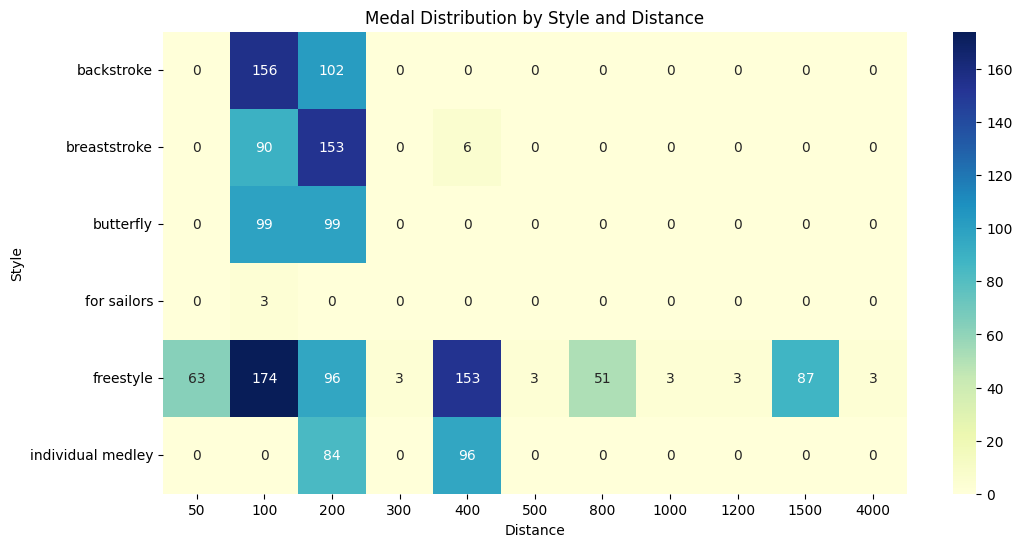

In [160]:
# Aggregate medals by Style and Distance
style_distance = df_eda.groupby(['Style','Distance'])[['Gold','Silver','Bronze']].sum()
style_distance['Total'] = style_distance[['Gold','Silver','Bronze']].sum(axis=1)  # total medals per style & distance
style_distance = style_distance.reset_index()

# Pivot data to create a matrix for the heatmap
heatmap_data = style_distance.pivot(index='Style', columns='Distance', values='Total').fillna(0)

# Plot heatmap using seaborn
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlGnBu')  # annotations show total medals as integers
plt.title("Medal Distribution by Style and Distance")
plt.show()

In [161]:
# Select only the columns with timing information 
times_cols = ['Gold_Time','Silver_Time','Bronze_Time']

# Calculate average times per Style and Gender
time_avg = df_eda.groupby(['Style','Gender'])[times_cols].mean().reset_index()
display(time_avg)  # Display average times

,Style,Gender,Gold_Time,Silver_Time,Bronze_Time
0,backstroke,men,85.002558,86.015116,86.732791
1,backstroke,women,NaN,NaN,NaN
2,breaststroke,men,116.747381,117.816429,120.200244
3,breaststroke,women,NaN,NaN,NaN
4,butterfly,men,88.785758,89.522727,92.425806
5,butterfly,women,NaN,NaN,NaN
6,for sailors,men,NaN,NaN,NaN
7,freestyle,men,354.083818,360.165963,365.027222
8,freestyle,women,NaN,NaN,NaN
9,individual medley,men,119.213077,120.330769,120.946154


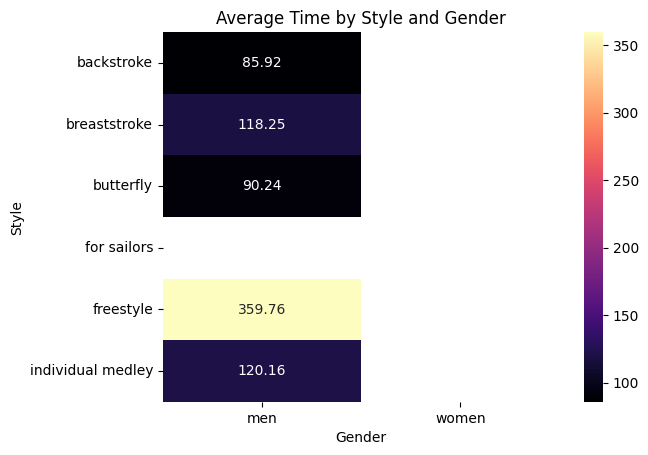

In [162]:
# Calculate overall average time per row (Gold/Silver/Bronze)
time_avg['Average_Time'] = time_avg[times_cols].mean(axis=1)

# Pivot for heatmap: Style as rows, Gender as columns, values = Average_Time
heatmap_time = time_avg.pivot(index='Style', columns='Gender', values='Average_Time')

# Plot heatmap of average times
sns.heatmap(heatmap_time, annot=True, fmt=".2f", cmap='magma')
plt.title("Average Time by Style and Gender")
plt.show()

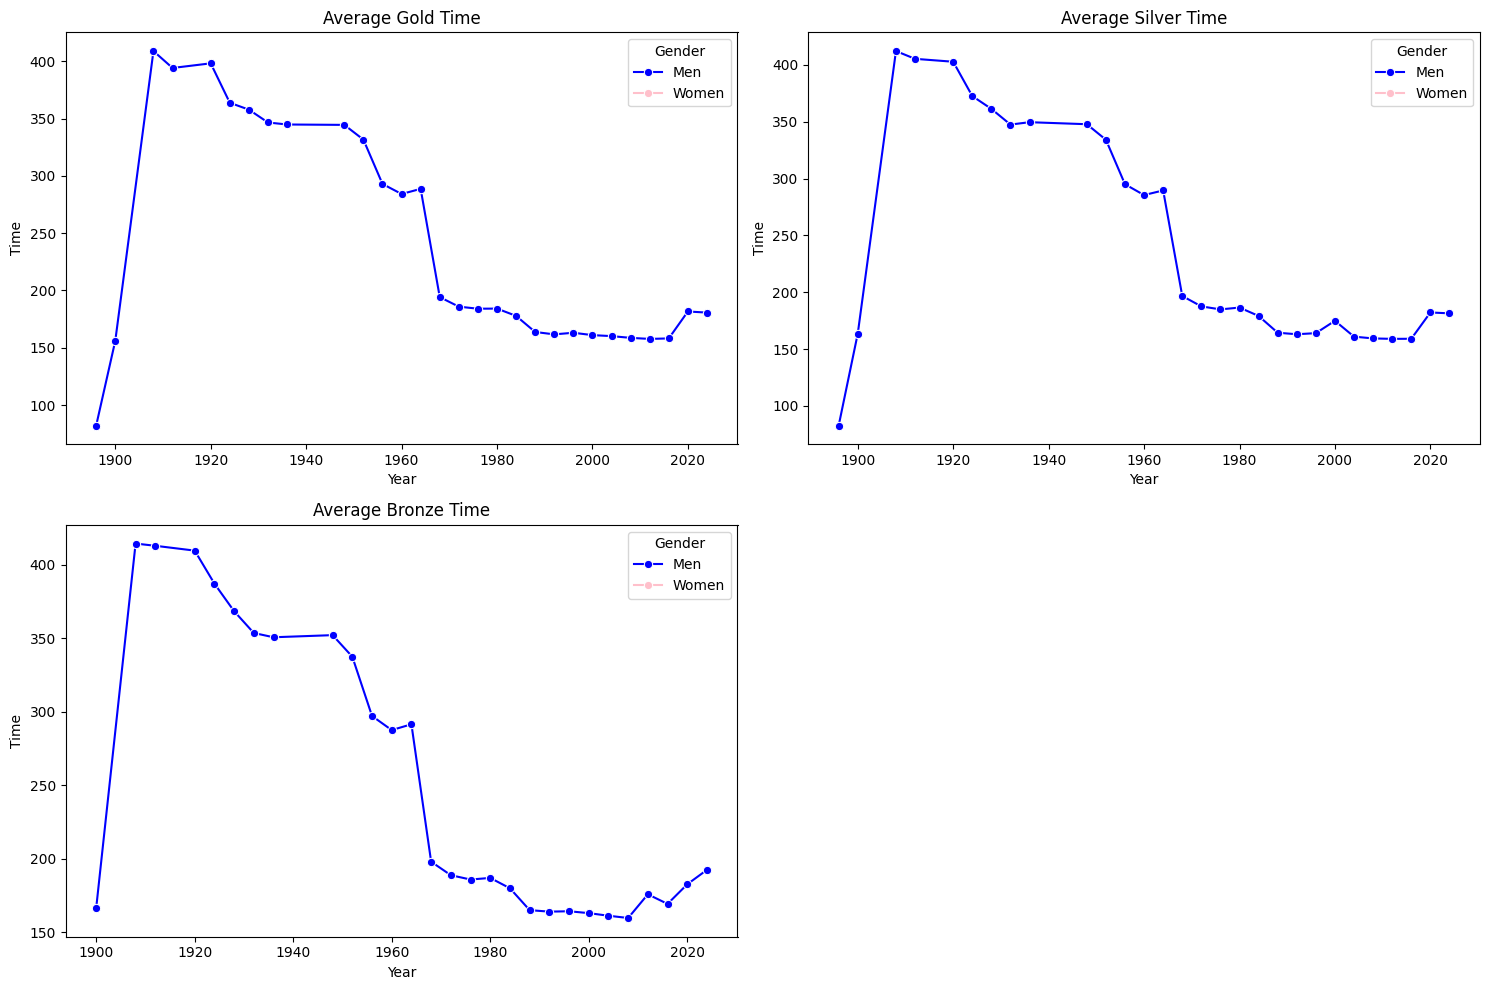

In [163]:
# Create 2x2 subplots (3 plots + 1 empty)
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()  # flatten to access axes as a list

# Prepare average times per year and gender 
gold_time = df_eda.groupby(['Games_Year','Gender'])['Gold_Time'].mean().reset_index()
silver_time = df_eda.groupby(['Games_Year','Gender'])['Silver_Time'].mean().reset_index()
bronze_time = df_eda.groupby(['Games_Year','Gender'])['Bronze_Time'].mean().reset_index()

# Gold time plot 
sns.lineplot(data=gold_time[gold_time['Gender']=='men'], x='Games_Year', y='Gold_Time', 
             marker='o', color='blue', label='Men', ax=axes[0])
sns.lineplot(data=gold_time[gold_time['Gender']=='women'], x='Games_Year', y='Gold_Time', 
             marker='o', color='pink', label='Women', ax=axes[0])
axes[0].set_title("Average Gold Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Time")
axes[0].legend(title='Gender')

# Silver time plot 
sns.lineplot(data=silver_time[silver_time['Gender']=='men'], x='Games_Year', y='Silver_Time', 
             marker='o', color='blue', label='Men', ax=axes[1])
sns.lineplot(data=silver_time[silver_time['Gender']=='women'], x='Games_Year', y='Silver_Time', 
             marker='o', color='pink', label='Women', ax=axes[1])
axes[1].set_title("Average Silver Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Time")
axes[1].legend(title='Gender')

# Bronze time plot 
sns.lineplot(data=bronze_time[bronze_time['Gender']=='men'], x='Games_Year', y='Bronze_Time', 
             marker='o', color='blue', label='Men', ax=axes[2])
sns.lineplot(data=bronze_time[bronze_time['Gender']=='women'], x='Games_Year', y='Bronze_Time', 
             marker='o', color='pink', label='Women', ax=axes[2])
axes[2].set_title("Average Bronze Time")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Time")
axes[2].legend(title='Gender')

# Leave the last subplot empty 
axes[3].axis('off')

# show plot
plt.tight_layout()
plt.show()


In [164]:
# Summary statistics for Gold times by Event and Gender
summary_stats = df_eda.groupby(['Event_Title','Gender']).agg(
    avg_time=('Gold_Time','mean'),      # Average Gold time
    median_time=('Gold_Time','median'), # Median Gold time
    max_time=('Gold_Time','max'),       # Maximum Gold time
    min_time=('Gold_Time','min'),       # Minimum Gold time
    count=('Gold_Time','count')         # Number of observations with Gold time
).reset_index()

# Preview the first rows of the summary statistics
summary_stats.head()

,Event_Title,Gender,avg_time,median_time,max_time,min_time,count
0,100 metre backstroke,men,61.055769,56.555,84.6,51.97,26
1,100 metre backstroke,women,NaN,NaN,NaN,NaN,0
2,100 metre breaststroke,men,61.091333,60.650,67.7,57.13,15
3,100 metre breaststroke,women,NaN,NaN,NaN,NaN,0
4,100 metre butterfly,men,52.392667,52.270,55.9,49.45,15


In [165]:
# min, max, and mean times for each Style, Distance, and Gender
df_stats = df_eda.groupby(['Style','Distance','Gender'])[['Gold_Time','Silver_Time','Bronze_Time']] \
                 .agg(['min','max','mean']) \
                 .reset_index()

# Display the resulting statistics
display(df_stats)

Style Distance Gender Gold_Time                        \
                                            min      max         mean   
0          backstroke      100    men     51.97    84.60    61.055769   
1          backstroke      100  women       NaN      NaN          NaN   
2          backstroke      200    men    113.27   167.00   121.627059   
3          backstroke      200  women       NaN      NaN          NaN   
4        breaststroke      100    men     57.13    67.70    61.091333   
5        breaststroke      100  women       NaN      NaN          NaN   
6        breaststroke      200    men    125.85   189.20   147.667407   
7        breaststroke      200  women       NaN      NaN          NaN   
8        breaststroke      400    men       NaN      NaN          NaN   
9           butterfly      100    men     49.45    55.90    52.392667   
10          butterfly      100  women       NaN      NaN          NaN   
11          butterfly      200    men    111.21   139.30   119.113333   
12          butterfly      200  women       NaN      NaN          NaN   
13        for sailors      100    men       NaN      NaN          NaN   
14          freestyle       50    men     21.07    22.14    21.645000   
15          freestyle       50  women       NaN      NaN          NaN   
16          freestyle      100    men     46.40    82.20    54.171786   
17          freestyle      100  women       NaN      NaN          NaN   
18          freestyle      200    men    102.96   145.20   109.503125   
19          freestyle      200  women       NaN      NaN          NaN   
20          freestyle      300  women       NaN      NaN          NaN   
21          freestyle      400    men    220.14   336.80   256.045926   
22          freestyle      400  women       NaN      NaN          NaN   
23          freestyle      500    men       NaN      NaN          NaN   
24          freestyle      800    men    458.19   461.87   460.030000   
25          freestyle      800  women       NaN      NaN          NaN   
26          freestyle     1000    men       NaN      NaN          NaN   
27          freestyle     1200    men       NaN      NaN          NaN   
28          freestyle     1500    men    870.67  1368.40  1023.355926   
29          freestyle     1500  women       NaN      NaN          NaN   
30          freestyle     4000    men       NaN      NaN          NaN   
31  individual medley      200    men    114.06   132.00   119.213077   
32  individual medley      200  women       NaN      NaN          NaN   
33  individual medley      400    men       NaN      NaN          NaN   
34  individual medley      400  women       NaN      NaN          NaN   

   Silver_Time                       Bronze_Time                        
           min      max         mean         min      max         mean  
0        52.00    86.60    61.906154       52.19    87.00    62.565385  
1          NaN      NaN          NaN         NaN      NaN          NaN  
2       113.78   176.00   122.887647      113.94   181.00   123.694706  
3          NaN      NaN          NaN         NaN      NaN          NaN  
4        58.00    68.00    61.468000       58.33    68.00    61.993571  
5          NaN      NaN          NaN         NaN      NaN          NaN  
6       126.79   192.80   149.121111      127.13   194.60   150.381481  
7          NaN      NaN          NaN         NaN      NaN          NaN  
8          NaN      NaN          NaN         NaN      NaN          NaN  
9        49.68    56.40    52.655333       50.45    57.20    53.253846  
10         NaN      NaN          NaN         NaN      NaN          NaN  
11      111.75   143.80   120.245556      112.80   143.90   120.716667  
12         NaN      NaN          NaN         NaN      NaN          NaN  
13         NaN      NaN          NaN         NaN      NaN          NaN  
14       21.30    22.36    21.766667       21.49    22.71    21.905000  
15         NaN      NaN          NaN         NaN      NaN          NaN  


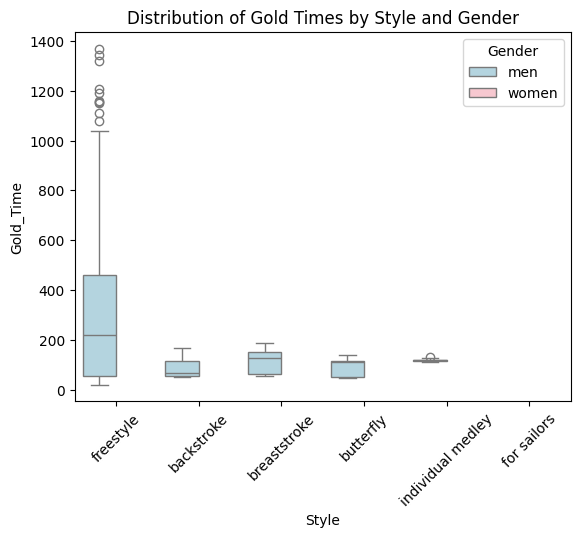

In [166]:
# Boxplot of Gold Times by Style and Gender 
# Men in light blue, Women in pink
sns.boxplot(
    data=df_eda,
    x='Style',
    y='Gold_Time',
    hue='Gender',
    palette={'men':'lightblue', 'women':'pink'}  # Set custom colors
)
plt.title("Distribution of Gold Times by Style and Gender")
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()

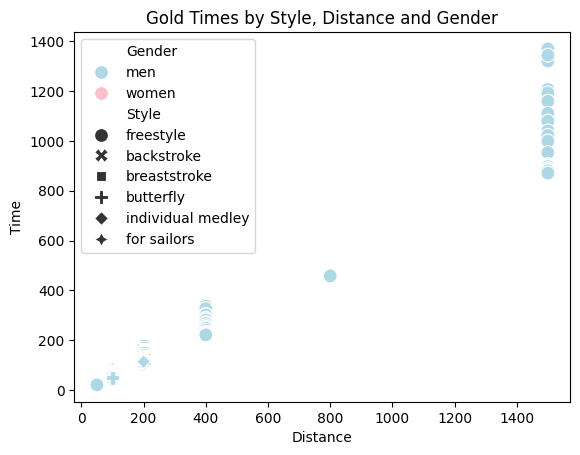

In [167]:
# Scatter plot of Gold Times by Style, Distance, and Gender 
# Men in light blue, Women in pink
sns.scatterplot(
    data=df_eda,
    x='Distance',
    y='Gold_Time',
    hue='Gender',
    style='Style',
    palette={'men':'lightblue', 'women':'pink'},  # Custom colors
    s=100  # Point size
)
plt.title("Gold Times by Style, Distance and Gender")
plt.ylabel("Time")
plt.xlabel("Distance")
plt.show()

In [168]:
# Convert from wide to long format for athlete medal analysis
df_long = pd.melt(
    df_eda,
    id_vars=['Gender', 'Style', 'Distance'],        # Keep these columns as identifiers
    value_vars=['Gold_Athlete', 'Silver_Athlete', 'Bronze_Athlete'],  # Melt medal columns
    var_name='Medal_Type',                          # Name of the new column indicating medal type
    value_name='Athlete'                            # Name of the new column holding athlete names
)

# Remove rows with missing athlete information 
df_long = df_long.dropna(subset=['Athlete'])

# Count medals per athlete within each Gender + Style + Distance group 
athlete_counts = df_long.groupby(['Gender', 'Style', 'Distance', 'Athlete']).size().reset_index(name='Medal_Count')

# Sort to get top athletes per group ---
top_athletes = athlete_counts.sort_values(
    ['Gender','Style','Distance','Medal_Count'], 
    ascending=[True, True, True, False]
)

# Get top 3 athletes per Gender + Style + Distance group as example 
top_3_per_group = top_athletes.groupby(['Gender','Style','Distance']).head(3)

top_3_per_group

,Gender,Style,Distance,Athlete,Medal_Count
50,men,backstroke,100,Roland Matthes,3
52,men,backstroke,100,Ryan Murphy,3
64,men,backstroke,100,not included in the Olympic,3
65,men,backstroke,200,Aaron Peirsol,3
109,men,backstroke,200,not included in the Olympic,3
...,...,...,...,...,...
1207,women,individual medley,200,Daniela Hunger,2
1209,women,individual medley,200,Kate Douglass,2
1244,women,individual medley,400,Emma Weyant,2
1254,women,individual medley,400,Krisztina Egerszegi,2


In [169]:
# Convert from wide to long format (Gold/Silver/Bronze) 
df_long = pd.melt(
    df_eda,
    id_vars=['Gender', 'Style', 'Distance'],       # Keep these as identifier columns
    value_vars=['Gold_Athlete','Silver_Athlete','Bronze_Athlete'],  # Melt medal columns
    var_name='Medal_Type',                         # Name of new column indicating medal type
    value_name='Athlete'                           # Name of new column holding athlete names
)

# Remove rows where athlete information is missing
df_long = df_long.dropna(subset=['Athlete'])

# Count total medals per Gender, Style, and Distance 
style_distance_counts = df_long.groupby(['Gender', 'Style', 'Distance']).size().reset_index(name='Total_Medals')

# Sort to see top styles/distances by Gender
style_distance_counts_sorted = style_distance_counts.sort_values(['Gender','Total_Medals'], ascending=[True, False])

# Display the sorted counts
style_distance_counts_sorted

,Gender,Style,Distance,Total_Medals
9,men,freestyle,100,87
0,men,backstroke,100,81
3,men,breaststroke,200,81
11,men,freestyle,400,81
16,men,freestyle,1500,81
1,men,backstroke,200,54
6,men,butterfly,200,54
10,men,freestyle,200,51
19,men,individual medley,400,48
2,men,breaststroke,100,45


In [170]:
# Filter only men
men_times = df_eda[df_eda['Gender'] == 'men'].copy()

# Remove rows with Style 'For Sailors'
men_times = men_times[men_times['Style'] != 'For Sailors']

# Group by Style and calculate statistics (mean, min, max) for each medal type
time_stats = men_times.groupby('Style')[['Gold_Time', 'Silver_Time', 'Bronze_Time']].agg(['mean','min','max'])

# Display the stats
time_stats

Gold_Time                 Silver_Time                  \
                         mean     min     max        mean     min     max   
Style                                                                       
backstroke          85.002558   51.97   167.0   86.015116   52.00   176.0   
breaststroke       116.747381   57.13   189.2  117.816429   58.00   192.8   
butterfly           88.785758   49.45   139.3   89.522727   49.68   143.8   
for sailors               NaN     NaN     NaN         NaN     NaN     NaN   
freestyle          354.083818   21.07  1368.4  360.165963   21.30  1371.2   
individual medley  119.213077  114.06   132.0  120.330769  114.90   133.0   

                  Bronze_Time                  
                         mean     min     max  
Style                                          
backstroke          86.732791   52.19   181.0  
breaststroke       120.200244   58.33   194.6  
butterfly           92.425806   50.45   143.9  
for sailors               NaN     NaN     NaN  
freestyle          365.027222   21.49  1395.4  
individual medley  120.946154  116.00   133.3

In [171]:
# Rows where all medal times (Gold, Silver, Bronze) are missing
no_times_events = men_times[
    men_times[['Gold_Time','Silver_Time','Bronze_Time']].isna().all(axis=1)
][['Games', 'Event_Title', 'Style', 'Distance']]

# Display events with no recorded times
no_times_events

,Games,Event_Title,Style,Distance
11,1900–1904,100 metre freestyle,freestyle,100
40,1904–1964,200 metre freestyle,freestyle,200
123,1964 Tokyo,100 metre backstroke,backstroke,100
140,1904–1960,200 metre backstroke,backstroke,200
234,1976–1980,200 metre individual medley,individual medley,200
246,1964 Tokyo,400 metre individual medley,individual medley,400
247,1968 Mexico City,400 metre individual medley,individual medley,400
248,1972 Munich,400 metre individual medley,individual medley,400
249,1976 Montreal,400 metre individual medley,individual medley,400
250,1980 Moscow,400 metre individual medley,individual medley,400


In [172]:
import os
import pandas as pd
from datetime import datetime  # ← para timestamp

#  Prepare data 
# Flatten MultiIndex columns if needed
if isinstance(time_stats.columns, pd.MultiIndex):
    time_stats.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col 
                          for col in time_stats.columns]

#  Create a blacklist DataFrame 
blacklist_dfs = []

for gender, tables in all_tables.items():  # all_tables contains lists of DataFrames
    for i, df_tmp in enumerate(tables):
        title = df_tmp.columns.name if df_tmp.columns.name else f"Table_{i}"
        if any(term.lower() in title.lower() for term in blacklist):
            df_copy = df_tmp.copy()
            df_copy['Gender'] = gender
            df_copy['Original_Title'] = title
            blacklist_dfs.append(df_copy)

df_blacklist = pd.concat(blacklist_dfs, ignore_index=True) if blacklist_dfs else pd.DataFrame()

#  Create outputs folder 
os.makedirs("outputs", exist_ok=True)

#  Generate timestamp 
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

#  Export to Excel 
excel_path = os.path.join("outputs", f"olympics_swimming_clean_{timestamp}.xlsx")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_eda.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    time_stats.to_excel(writer, sheet_name='Time_Stats', index=False)
    no_times_events.to_excel(writer, sheet_name='Events_No_Times', index=False)
    df_eda_medals.to_excel(writer, sheet_name='Medals_By_Country', index=False)
    df_blacklist.to_excel(writer, sheet_name='Blacklist', index=False)

print(f"Excel exported successfully to: {excel_path}")

#  Export CSV 
csv_path_eda = os.path.join("outputs", f"df_eda_{timestamp}.csv")
csv_path_medals = os.path.join("outputs", f"df_eda_medals_{timestamp}.csv")

df_eda.to_csv(csv_path_eda, index=False)
df_eda_medals.to_csv(csv_path_medals, index=False)

print(f"CSV df_eda exported: {csv_path_eda}")
print(f"CSV df_eda_medals exported: {csv_path_medals}")

Excel exported successfully to: outputs\olympics_swimming_clean_20260328_190137.xlsx
CSV df_eda exported: outputs\df_eda_20260328_190137.csv
CSV df_eda_medals exported: outputs\df_eda_medals_20260328_190137.csv
